# Converting to PyG graphs

Again, start from a `PyVista` dataset:

In [35]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [36]:
from cooldata.pyvista_flow_field_dataset import PyvistaFlowFieldDataset

ds_pv = PyvistaFlowFieldDataset.load_from_huggingface(
    num_samples=2, data_dir="datasets/pyvista"
)
ds_pv[0]

Loaded 2 samples from '/Users/ole/Documents/software/flow_field_dataset/docs/usage/datasets/pyvista'.
Loaded 2 samples from 'datasets/pyvista'.


2025-06-09 07:10:06.424 ( 461.604s) [          760B75]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x3201dc720): Skipping BC_t node: BC_t type 'BCInflow' not supported yet.
2025-06-09 07:10:06.425 ( 461.605s) [          760B75]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x3201dc720): Skipping BC_t node: BC_t type 'BCSymmetryPlane' not supported yet.
2025-06-09 07:10:06.425 ( 461.605s) [          760B75]      vtkCGNSReader.cxx:4267  WARN| vtkCGNSReader (0x3201dc720): Skipping BC_t node: BC_t type 'BCTunnelOutflow' not supported yet.


Now, let us convert the `PyVista` dataset to a `DGL` graph. This requires some computation, and is implemented in a parallelized way. Also, you need to install the `dgl` library (see [here](https://www.dgl.ai/pages/start.html)).

In [37]:
from cooldata.pyg_flow_field_dataset import PyGSurfaceFlowFieldDataset

ds_pyg_surface = PyGSurfaceFlowFieldDataset(
    "datasets/pyg_surface", ds_pv, normalize=False

)

Let us now explore what the graphs look like:

In [38]:
ds_pyg_surface[0]

Data(edge_index=[2, 286210], Pressure=[35771], Temperature=[35771], pos=[35771, 3], ShearStress=[35771, 3], Normal=[35771, 3], CellArea=[35771], SurfaceType=[35771], BodyID=[35771], HeatTransferCoefficient=[35771], edge_attr=[286210, 3])

Again, we can visualize the graph:

In [39]:
import pyvista as pv
pv.set_jupyter_backend('static')

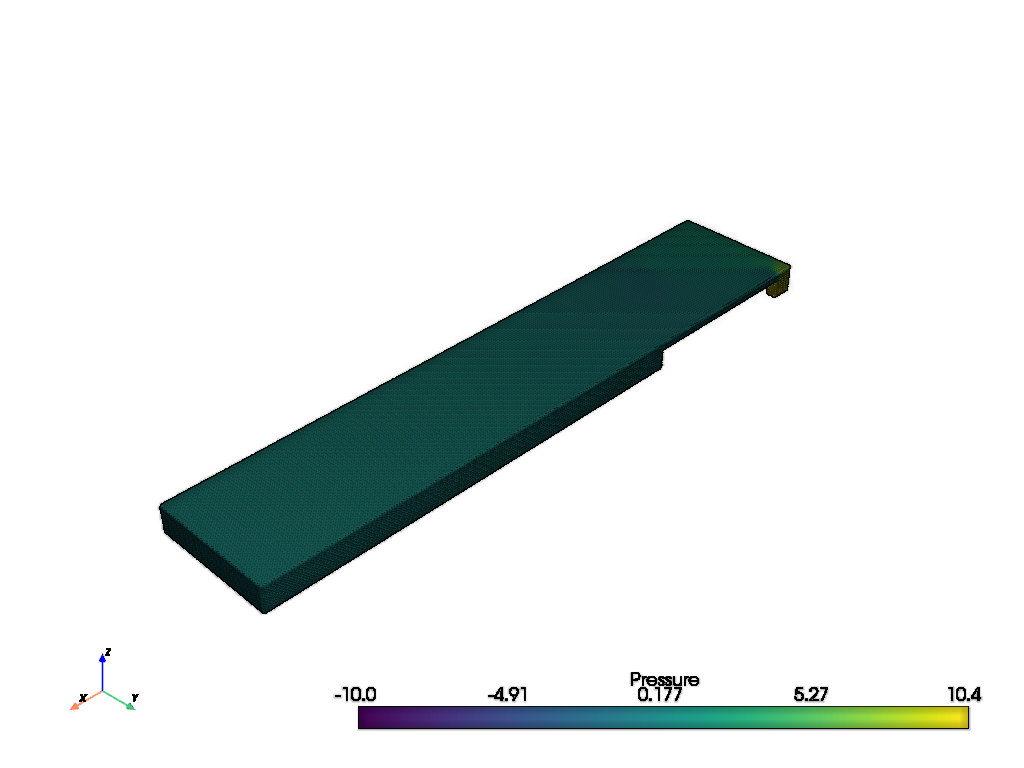

In [40]:
ds_pyg_surface.plot_surface(ds_pyg_surface[0],"Pressure")

Now, let us normalize the data:

In [41]:
ds_pyg_surface[0]["Pressure"].mean()

tensor(0.1086)

In [42]:
ds_pyg_surface.do_normalization = True
ds_pyg_surface[0]["Pressure"].mean()

tensor(0.3887)

You can find a full training script [here](https://github.com/peteole/flow_field_dataset/blob/main/examples/meshgraphnet/train.ipynb).

It is possible to use the volumetric data as a graph as well:

In [43]:
from cooldata.pyg_flow_field_dataset import PyGVolumeFlowFieldDataset


ds_pyg_volume = PyGVolumeFlowFieldDataset("datasets/pyg_volume", ds_pv)

The graphs will have a significantly larger number of nodes and edges:

In [44]:
ds_pyg_volume[0]

Data(edge_index=[2, 4550210], Pressure=[187194], Temperature=[187194], pos=[187194, 3], Velocity=[187194, 3], TurbulentDissipationRate=[187194], TurbulentKineticEnergy=[187194], Volume=[187194], edge_attr=[4550210, 3])

Again, we can normalize the graph features:

In [45]:
ds_pyg_volume[0]["Pressure"].mean(), ds_pyg_volume[0]["Pressure"].std(),

(tensor(0.0291), tensor(0.7165))

In [46]:
ds_pyg_volume.normalize()
ds_pyg_volume[0]["Pressure"].mean(),ds_pyg_volume[0]["Pressure"].std()

(tensor(0.3601), tensor(0.3279))